In [86]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [109]:
star_file = h5py.File("input/star_2022.h5", "r")

In [110]:
star_file['r50_kdistr']['phoenix'].keys()

<KeysViewHDF5 ['gj1214']>

In [111]:
#get wavelength grid from opacity file
opac_file = h5py.File("ktable/output/r50_kdistr/mixed/mixed_opac_kdistr.h5", "r")

In [112]:
opac_file['center wavelengths']

<HDF5 dataset "center wavelengths": shape (385,), type "<f8">

In [113]:
opac_file['interface wavelengths']

<HDF5 dataset "interface wavelengths": shape (386,), type "<f8">

In [114]:
opac_file['wavelength width of bins']

<HDF5 dataset "wavelength width of bins": shape (385,), type "<f8">

In [116]:
#load mason spectrum
mason_data = np.loadtxt("input/spectra/WASP15_spectrum.txt", skiprows=1)

In [117]:
mason_data

array([[1.16735000e+02, 1.84887749e+08],
       [1.16902000e+02, 1.65292531e+08],
       [1.17070000e+02, 1.34275704e+08],
       ...,
       [1.20000000e+05, 5.09172083e+02],
       [1.40000000e+05, 2.73577660e+02],
       [1.60000000e+05, 1.59706166e+02]], shape=(1815, 2))

In [118]:
print(opac_file['units'])

<HDF5 dataset "units": shape (), type "|O">


In [119]:
# Print actual data from the HDF5 datasets (not just the dataset objects)
def _print_dataset(name, ds, max_items=10):
    data = ds[:]
    print(f"{name} (shape {getattr(data, 'shape', None)}):")
    # For 1D or 2D arrays print a limited preview to avoid huge dumps
    if hasattr(data, 'size') and data.size > max_items:
        # show first rows/elements
        if data.ndim == 1:
            print(data[:max_items], "...")
        else:
            print(data[:min(max_items, data.shape[0])], "...")
    else:
        print(data)
    print()

_print_dataset("center wavelengths", opac_file['center wavelengths'])
_print_dataset("interface wavelengths", opac_file['interface wavelengths'])
_print_dataset("wavelength width of bins", opac_file['wavelength width of bins'])

# 'units' is often a scalar string/bytes dataset
_units = opac_file['units'][()]
if isinstance(_units, bytes):
    try:
        _units = _units.decode('utf-8')
    except Exception:
        _units = str(_units)
print("units:", _units)

center wavelengths (shape (385,)):
[2.46440000e-05 2.51368800e-05 2.56396176e-05 2.61524100e-05
 2.66754582e-05 2.72089673e-05 2.77531467e-05 2.83082096e-05
 2.88743738e-05 2.94518613e-05] ...

interface wavelengths (shape (386,)):
[2.44000000e-05 2.48880000e-05 2.53857600e-05 2.58934752e-05
 2.64113447e-05 2.69395716e-05 2.74783630e-05 2.80279303e-05
 2.85884889e-05 2.91602587e-05] ...

wavelength width of bins (shape (385,)):
[4.88000000e-07 4.97760000e-07 5.07715200e-07 5.17869504e-07
 5.28226894e-07 5.38791432e-07 5.49567261e-07 5.60558606e-07
 5.71769778e-07 5.83205173e-07] ...

units: CGS


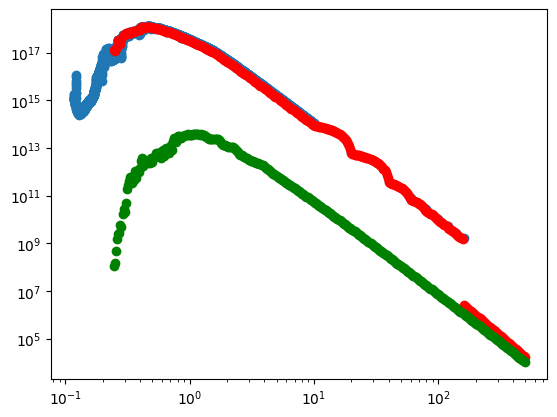

In [120]:
plt.scatter(mason_data[:,0]*1e-3, mason_data[:,1]*1e7, label='mason file')
# plt.xlim(0.3, 5)
plt.scatter(wave_centers, binned_spectrum, color='r', label='binned spectrum')
plt.scatter(wave_centers, star_file['r50_kdistr']['phoenix']['gj1214'][:], color='g', label='phoenix spectrum')
plt.yscale('log')
plt.xscale('log')

In [97]:
#get binned spectrum
wave_centers = opac_file['center wavelengths'][:]*1e4  # convert to microns

In [104]:
binned_mason = h5py.File("star_tool/output/WASP17.h5", "r")

In [105]:
wave_centers = binned_mason['r50_kdistr']['lambda'][:]*1e4

In [107]:
binned_spectrum = binned_mason['r50_kdistr']['ascii']['WASP17'][:]

In [103]:
#close all files
star_file.close()
opac_file.close()
binned_mason.close()